# AIME vs SHAP and LIME — What Is Different About an Inverse Explanation?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ntakafumi/aime/blob/main/examples/colab/02_aime_vs_shap_lime.ipynb)

This notebook uses the same multiclass black-box model and the same test instance to contrast three explanation objects:

- **AIME:** one approximate inverse operator `A†`, from which global, local, and representative-input explanations are derived;
- **SHAP:** additive feature attributions relative to a reference expectation;
- **LIME:** coefficients of a locally fitted surrogate model around one instance.

The methods answer different questions. Their values should **not** be treated as interchangeable or compared on an absolute numerical scale.


## 0. Install the comparison packages

Versions are pinned to keep the example reproducible in Colab.


In [1]:
import importlib.util
import subprocess
import sys

requirements = {
    "aime_xai": "aime-xai==1.2.0",
    "shap": "shap==0.50.0",
    "lime": "lime==0.2.0.1",
}
missing = [spec for module, spec in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


In [2]:
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

import shap
from lime.lime_tabular import LimeTabularExplainer

import aime_xai
from aime_xai import AIME
import aime_xai.style as S

S.set_publication_mode(False)

def package_version(name: str) -> str:
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return "available"

print("aime_xai:", aime_xai.__version__)
print("shap:", shap.__version__)
print("lime:", package_version("lime"))


aime_xai: 1.2.0
shap: 0.52.0
lime: 0.2.0.1


## 1. Train one multiclass black-box model

The built-in Wine dataset has 13 continuous input features and three output classes, making the class-wise structure of `A†` visible without any external data download.


In [3]:
dataset = load_wine(as_frame=True)
X = dataset.data.astype(float)
y = dataset.target.astype(int)
feature_names = X.columns.tolist()
class_names = dataset.target_names.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_hat_train = model.predict_proba(X_train)
y_hat_test = model.predict_proba(X_test)

print("test accuracy:", round(accuracy_score(y_test, model.predict(X_test)), 3))
print("input features:", len(feature_names), "| output classes:", len(class_names))


test accuracy: 1.0
input features: 13 | output classes: 3


## 2. AIME first learns one inverse operator

The global view is native to `A†`: every output class has its own signed input-feature vector.


A† shape: (13, 3)


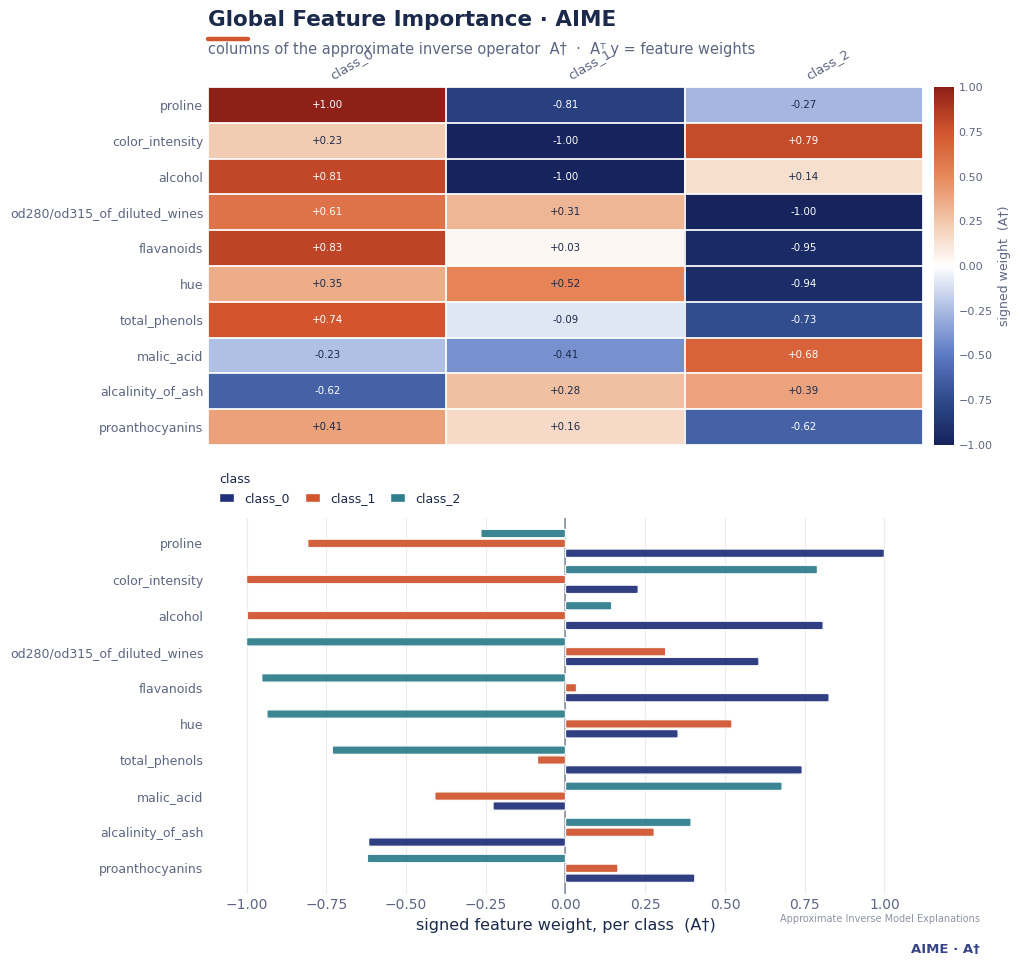

,proline,color_intensity,alcohol,od280/od315_of_diluted_wines,flavanoids,hue,total_phenols,malic_acid,alcalinity_of_ash,proanthocyanins
class_0,1.00,0.23,0.81,0.61,0.83,0.35,0.74,-0.23,-0.62,0.41
class_1,-0.81,-1.00,-1.00,0.31,0.03,0.52,-0.09,-0.41,0.28,0.16
class_2,-0.27,0.79,0.14,-1.00,-0.95,-0.94,-0.73,0.68,0.39,-0.62


In [4]:
aime = AIME().create_explainer(X_train, y_hat_train, normalize=True)
print("A† shape:", aime.A_dagger.shape)

aime_global = aime.global_feature_importance(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
    layout="vertical",
)
display(aime_global.round(2))


## 3. Select one difficult instance

We use the test point with the highest predictive entropy. All three local methods explain the same selected class for this same point.


In [5]:
entropy = -(y_hat_test * np.log(np.clip(y_hat_test, 1e-12, 1.0))).sum(axis=1)
focus_position = int(np.argmax(entropy))
focus_x = X_test.iloc[focus_position].to_numpy(dtype=float)
focus_y = y_hat_test[focus_position]
target_class = int(np.argmax(focus_y))

display(pd.Series(focus_y, index=class_names, name="probability").to_frame().round(3))
print("explained class:", class_names[target_class])


,probability
class_0,0.201
class_1,0.670
class_2,0.129


explained class: class_1


## 4. Compute the three local explanation vectors

For a class-aligned comparison, AIME is evaluated at the selected one-hot class basis `eₜ` rather than at the full probability vector. For visualization only, each vector is independently divided by its own maximum absolute value. This preserves signs and rankings within a method, but it does **not** make the three mathematical quantities equivalent.


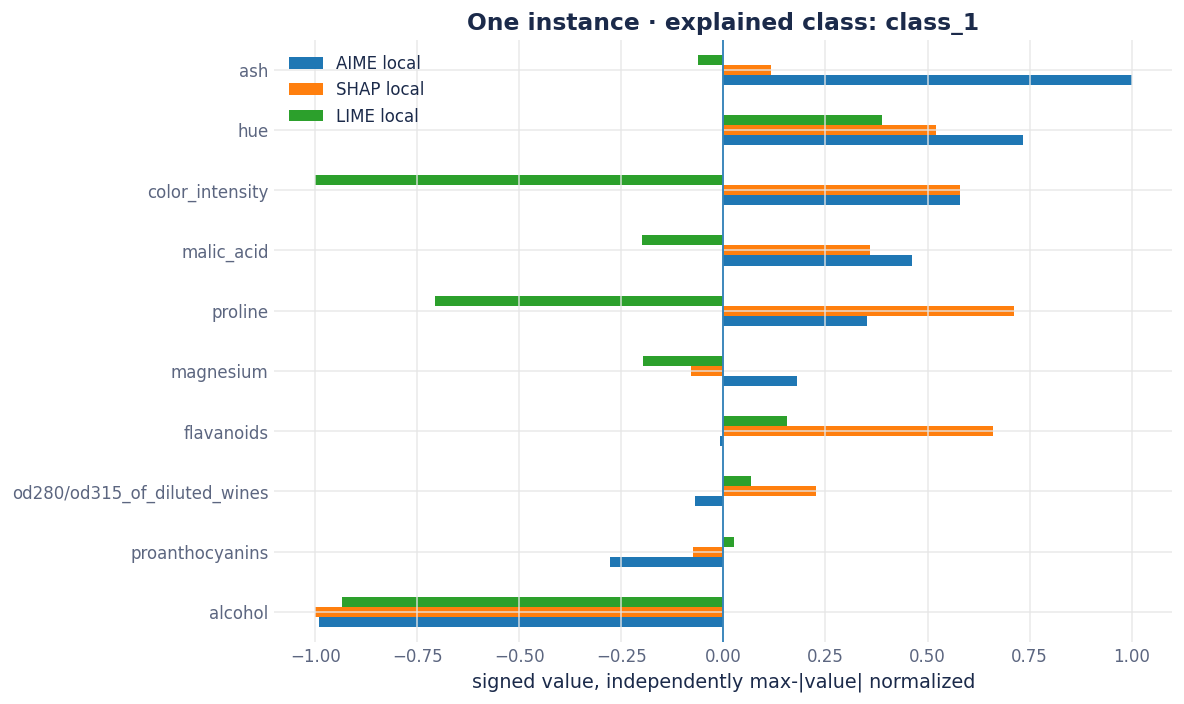

,AIME local,SHAP local,LIME local
alcohol,-0.990,-1.000,-0.936
proanthocyanins,-0.279,-0.075,0.025
od280/od315_of_diluted_wines,-0.070,0.226,0.068
flavanoids,-0.008,0.661,0.155
magnesium,0.181,-0.080,-0.198
proline,0.353,0.711,-0.706
malic_acid,0.462,0.359,-0.200
color_intensity,0.579,0.580,-1.000
hue,0.735,0.521,0.389
ash,1.000,0.118,-0.063


In [6]:
# AIME class-conditioned local inverse contribution: (A† eₜ) ⊙ x′
aime_target = np.zeros(len(class_names), dtype=float)
aime_target[target_class] = 1.0
aime_local = aime.local_feature_importance_without_viz(
    focus_x,
    aime_target,
    feature_names=feature_names,
    scaler=aime.scaler,
    ignore_zero_features=False,
).iloc[0].to_numpy()

# SHAP local additive attribution for the selected class.
shap_explanation = shap.TreeExplainer(model)(X_test.iloc[[focus_position]])
shap_values = np.asarray(shap_explanation.values)
if shap_values.ndim == 3 and shap_values.shape[-1] == len(class_names):
    shap_local = shap_values[0, :, target_class]
elif shap_values.ndim == 3 and shap_values.shape[0] == len(class_names):
    # Compatibility with older list/class-first layouts.
    shap_local = shap_values[target_class, 0, :]
elif shap_values.ndim == 2:
    shap_local = shap_values[0]
else:
    raise RuntimeError(f"Unexpected SHAP value shape: {shap_values.shape}")

# LIME local surrogate coefficient for the selected class.
lime_explainer = LimeTabularExplainer(
    X_train.to_numpy(),
    mode="classification",
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=False,
    random_state=42,
)

def predict_proba_array(values):
    frame = pd.DataFrame(values, columns=feature_names)
    return model.predict_proba(frame)

lime_explanation = lime_explainer.explain_instance(
    focus_x,
    predict_proba_array,
    labels=[target_class],
    num_features=len(feature_names),
    num_samples=2500,
)
lime_local = np.zeros(len(feature_names), dtype=float)
for feature_index, weight in lime_explanation.as_map()[target_class]:
    lime_local[feature_index] = weight

def max_abs_scale(values):
    values = np.asarray(values, dtype=float)
    scale = np.max(np.abs(values))
    return values / scale if scale > 0 else values

local_comparison = pd.DataFrame({
    "AIME local": max_abs_scale(aime_local),
    "SHAP local": max_abs_scale(shap_local),
    "LIME local": max_abs_scale(lime_local),
}, index=feature_names)

top_features = local_comparison.abs().max(axis=1).nlargest(10).index
local_plot = local_comparison.loc[top_features].sort_values("AIME local")

ax = local_plot.plot(kind="barh", figsize=(10, 6))
ax.axvline(0, linewidth=1)
ax.set_xlabel("signed value, independently max-|value| normalized")
ax.set_ylabel("")
ax.set_title(f"One instance · explained class: {class_names[target_class]}")
plt.tight_layout()
plt.show()

display(local_plot.round(3))


## 5. What is structurally different?

| Method | Fitted explanation object | Native scope | Class representative input |
|---|---|---|---|
| **AIME** | One inverse operator `A†` | Global and local from the same operator | `A† eₜ` is a native output |
| **SHAP** | Shapley-style additive attributions | Local; global summaries are usually aggregated from local values | Not a native output |
| **LIME** | One locally weighted surrogate per explanation | Local | Not a native output |

The comparison plot above asks how the three methods rank features for one point. The next cell shows an additional input-side object that follows directly from AIME's inverse formulation.


## 6. AIME representative input patterns

For each class basis vector `eₜ`, AIME computes `A† eₜ` and maps it back to the original feature scale. Read each row as the class-conditioned input fingerprint reconstructed by the inverse operator—not as a real observed wine sample.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,13.83,2.00,2.47,16.95,107.56,2.90,3.04,0.29,1.92,5.72,1.06,3.15,1151.74
class_1,12.14,1.87,2.22,20.67,93.82,2.23,2.03,0.36,1.70,2.56,1.07,2.82,492.65
class_2,13.14,3.42,2.46,21.65,99.87,1.61,0.65,0.45,1.07,7.75,0.64,1.59,628.46


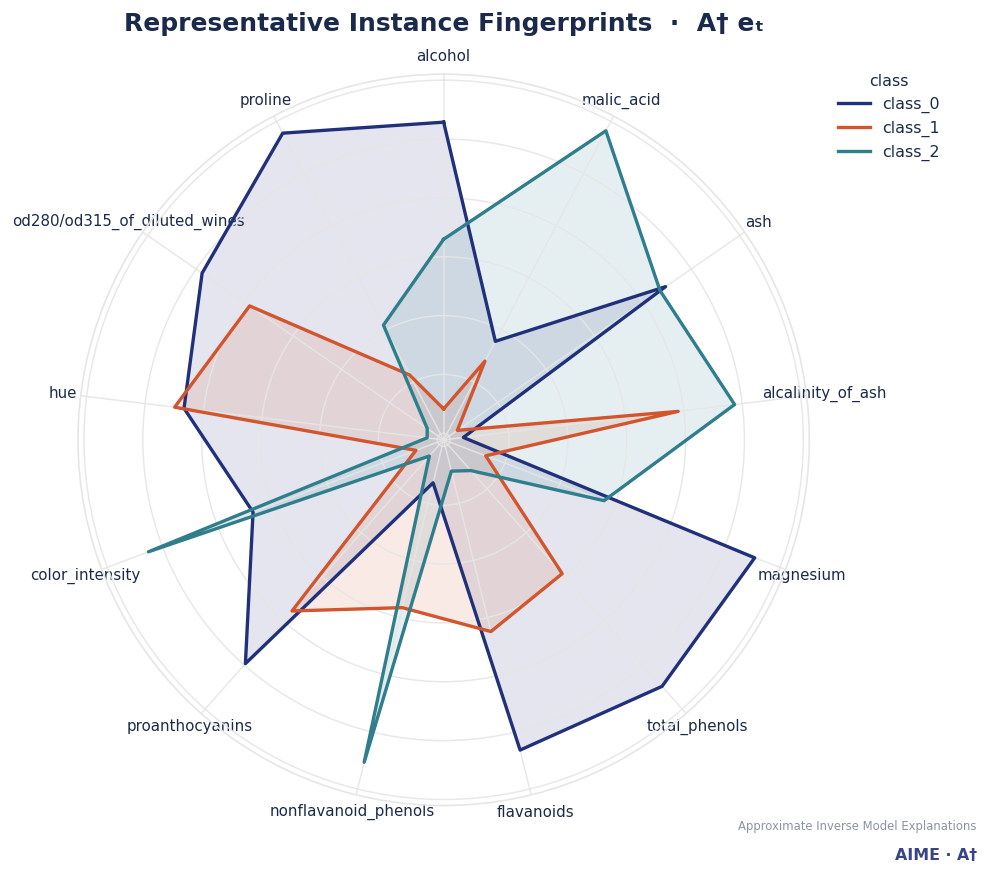

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,13.827448,2.004412,2.467025,16.945830,107.562591,2.902601,3.043501,0.290658,1.919728,5.723605,1.055576,3.145993,1151.738653
class_1,12.141145,1.871096,2.222942,20.670751,93.823128,2.225287,2.027860,0.361221,1.704234,2.562099,1.071630,2.817352,492.653338
class_2,13.139068,3.420769,2.460432,21.648824,99.867855,1.605785,0.652832,0.448637,1.069942,7.753440,0.639158,1.587925,628.461032


In [7]:
representative_inputs = aime.representative_instance(
    feature_names=feature_names,
    class_names=class_names,
)
display(representative_inputs.round(2))

aime.plot_representative_instance(
    feature_names=feature_names,
    class_names=class_names,
)


## 7. Trace the inverse direction explicitly

The ribbons run from output classes back to input features. Width encodes `|A†|`; color encodes the sign of the operator weight.


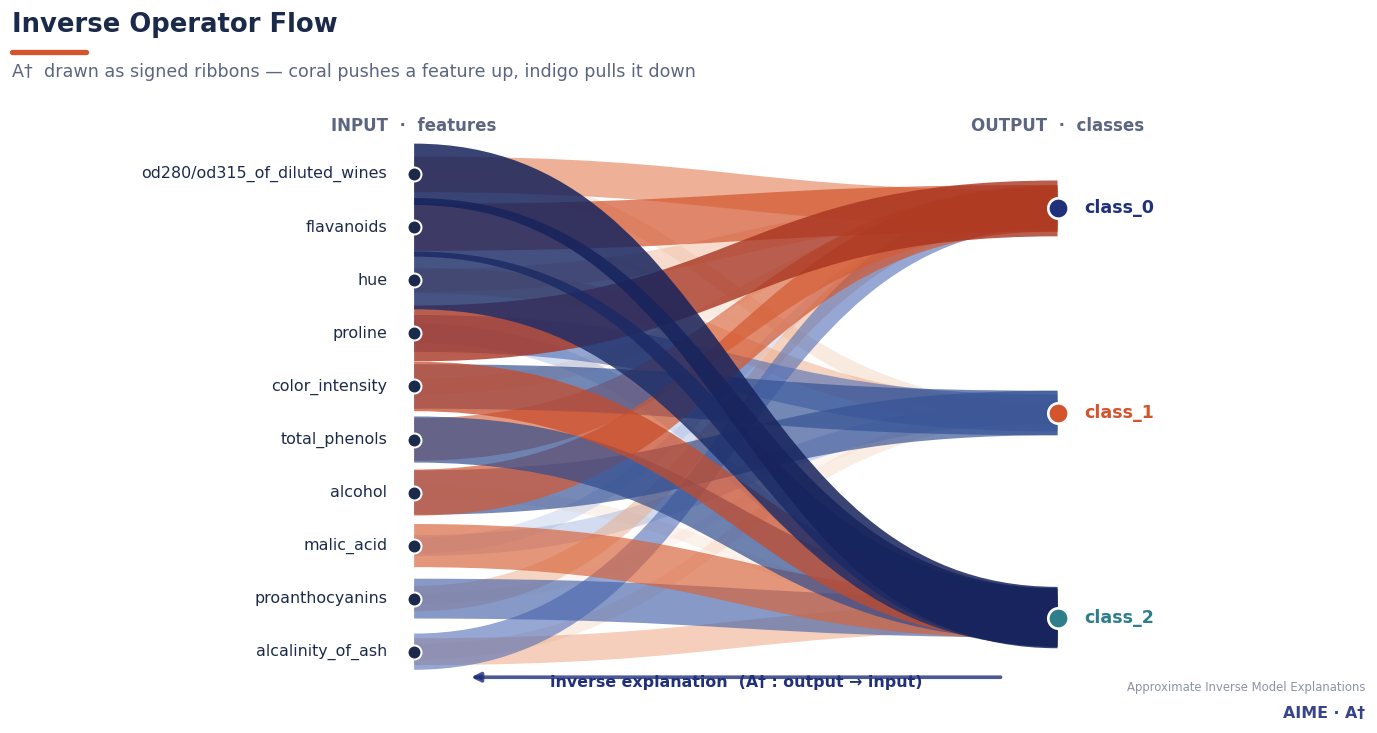

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
class_0,1.075475,-0.302460,0.373674,-0.821679,0.506676,0.988033,1.100128,-0.599312,0.539908,0.303717,0.470332,0.807366,1.331108
class_1,-1.035354,-0.425200,-0.545008,0.289008,-0.413836,-0.091126,0.036119,-0.001757,0.170719,-1.037751,0.541678,0.326041,-0.838674
class_2,0.213795,1.001539,0.348859,0.580647,-0.008853,-1.078174,-1.404394,0.738509,-0.915967,1.165002,-1.380292,-1.474570,-0.391580


In [8]:
aime.plot_inverse_operator_flow(
    feature_names=feature_names,
    class_names=class_names,
    top_k=10,
)


---

### Takeaway

SHAP and LIME remain useful attribution approaches, but AIME starts from a different mathematical object. Its central benefit is not merely another local ranking: the **same inverse operator** supplies per-class global weights, local Hadamard contributions, representative input patterns, and operator-level visualizations.
